# A/B Testing Analysis

## Project Goal

The goal of this notebook is to evaluate whether the advertising campaign had a statistically significant impact on user conversion.

We compare two groups:

- **ad**: users exposed to the advertising campaign;
- **psa**: users exposed to a public service announcement.

The main metric is **conversion rate**.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style="whitegrid")

In [4]:

df.head()

,unnamed:_0,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


## Group Overview

Before running the statistical test, we check the number of users and conversions in each group.

In [5]:
ab_summary = (
    df.groupby("test_group")["converted"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

ab_summary.columns = ["test_group", "users", "conversions", "conversion_rate"]
ab_summary["conversion_rate_%"] = (ab_summary["conversion_rate"] * 100).round(2)

ab_summary

,test_group,users,conversions,conversion_rate,conversion_rate_%
0,ad,564577,14423,0.025547,2.55
1,psa,23524,420,0.017854,1.79


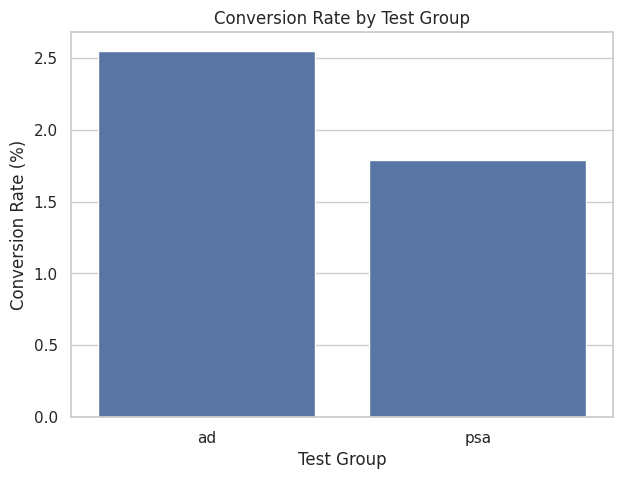

In [6]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=ab_summary,
    x="test_group",
    y="conversion_rate_%"
)

plt.title("Conversion Rate by Test Group")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

#### Observation

The conversion rate differs between the advertising group and the control group. However, we need a statistical test to determine whether this difference is statistically significant.

## Hypothesis Formulation

We define the hypotheses as follows:

**Null hypothesis (H0):**  
There is no difference in conversion rates between the advertising group and the control group.

**Alternative hypothesis (H1):**  
There is a difference in conversion rates between the advertising group and the control group.

We use a two-proportion z-test because the target metric is binary: converted or not converted.

In [7]:
ad_group = df[df["test_group"] == "ad"]
psa_group = df[df["test_group"] == "psa"]

ad_conversions = ad_group["converted"].sum()
psa_conversions = psa_group["converted"].sum()

ad_total = ad_group.shape[0]
psa_total = psa_group.shape[0]

print(f"Ad group users: {ad_total:,}")
print(f"Ad group conversions: {ad_conversions:,}")
print(f"Ad group conversion rate: {ad_conversions / ad_total * 100:.2f}%")

print()

print(f"PSA group users: {psa_total:,}")
print(f"PSA group conversions: {psa_conversions:,}")
print(f"PSA group conversion rate: {psa_conversions / psa_total * 100:.2f}%")

Ad group users: 564,577
Ad group conversions: 14,423
Ad group conversion rate: 2.55%

PSA group users: 23,524
PSA group conversions: 420
PSA group conversion rate: 1.79%


## Two-Proportion Z-test

The two-proportion z-test checks whether the difference between two conversion rates is statistically significant.

In [8]:
count = np.array([ad_conversions, psa_conversions])
nobs = np.array([ad_total, psa_total])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")

Z-statistic: 7.3701
P-value: 0.000000


## Statistical Test Result

In [9]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("The difference in conversion rates is statistically significant.")
else:
    print("Fail to reject the null hypothesis.")
    print("The difference in conversion rates is not statistically significant.")

Reject the null hypothesis.
The difference in conversion rates is statistically significant.


#### Observation

If the p-value is below 0.05, we reject the null hypothesis and conclude that the difference between the groups is statistically significant.

## Confidence Intervals

Confidence intervals show the likely range of conversion rates for each group.

In [10]:
ad_ci_low, ad_ci_upp = proportion_confint(
    count=ad_conversions,
    nobs=ad_total,
    alpha=0.05,
    method="normal"
)

psa_ci_low, psa_ci_upp = proportion_confint(
    count=psa_conversions,
    nobs=psa_total,
    alpha=0.05,
    method="normal"
)

ci_results = pd.DataFrame({
    "group": ["ad", "psa"],
    "conversion_rate_%": [
        ad_conversions / ad_total * 100,
        psa_conversions / psa_total * 100
    ],
    "ci_lower_%": [
        ad_ci_low * 100,
        psa_ci_low * 100
    ],
    "ci_upper_%": [
        ad_ci_upp * 100,
        psa_ci_upp * 100
    ]
})

ci_results = ci_results.round(2)

ci_results

,group,conversion_rate_%,ci_lower_%,ci_upper_%
0,ad,2.55,2.51,2.60
1,psa,1.79,1.62,1.95


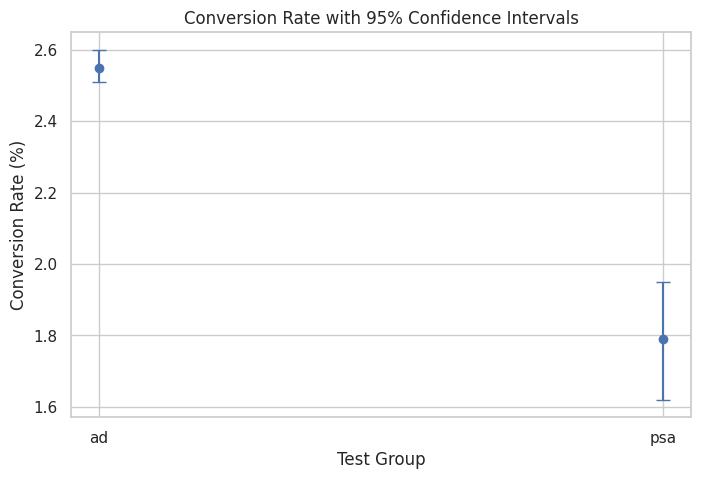

In [11]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    x=ci_results["group"],
    y=ci_results["conversion_rate_%"],
    yerr=[
        ci_results["conversion_rate_%"] - ci_results["ci_lower_%"],
        ci_results["ci_upper_%"] - ci_results["conversion_rate_%"]
    ],
    fmt="o",
    capsize=5
)

plt.title("Conversion Rate with 95% Confidence Intervals")
plt.xlabel("Test Group")
plt.ylabel("Conversion Rate (%)")
plt.show()

## Conversion Uplift

Uplift measures how much better the advertising group performed compared to the control group.

In [12]:
ad_conversion_rate = ad_conversions / ad_total
psa_conversion_rate = psa_conversions / psa_total

absolute_uplift = ad_conversion_rate - psa_conversion_rate
relative_uplift = absolute_uplift / psa_conversion_rate * 100

print(f"Ad conversion rate: {ad_conversion_rate * 100:.2f}%")
print(f"PSA conversion rate: {psa_conversion_rate * 100:.2f}%")
print(f"Absolute uplift: {absolute_uplift * 100:.2f} percentage points")
print(f"Relative uplift: {relative_uplift:.2f}%")

Ad conversion rate: 2.55%
PSA conversion rate: 1.79%
Absolute uplift: 0.77 percentage points
Relative uplift: 43.09%


#### Observation

Absolute uplift shows the difference in percentage points, while relative uplift shows how much the advertising group improved compared to the control group.

## Practical Impact

Statistical significance does not always mean business significance.  
This section estimates how many additional conversions the advertising campaign generated compared to the control conversion rate.

In [13]:
expected_conversions_at_control_rate = ad_total * psa_conversion_rate
additional_conversions = ad_conversions - expected_conversions_at_control_rate

print(f"Expected conversions at PSA conversion rate: {expected_conversions_at_control_rate:,.0f}")
print(f"Actual conversions in ad group: {ad_conversions:,.0f}")
print(f"Estimated additional conversions: {additional_conversions:,.0f}")

Expected conversions at PSA conversion rate: 10,080
Actual conversions in ad group: 14,423
Estimated additional conversions: 4,343


# Final Business Decision

Based on the A/B test results:

- The advertising group has a higher conversion rate than the control group.
- The two-proportion z-test determines whether this difference is statistically significant.
- Confidence intervals help estimate the uncertainty around conversion rates.
- Uplift shows the practical effect of the campaign.

If the p-value is below 0.05 and the uplift is positive, the advertising campaign can be considered effective and may be recommended for further use.

However, before full-scale implementation, the company should also consider advertising cost, customer acquisition cost, and expected revenue per conversion.

# Key Findings

- The advertising campaign produced a measurable difference in conversion rate compared to the control group.
- The statistical test helps determine whether this difference is unlikely to be due to random chance.
- The uplift analysis translates statistical results into business impact.
- Final implementation should depend not only on statistical significance, but also on campaign profitability.